## **Exploratory Data Analysis**

In [35]:
## import our libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import umap

## **Limitations of Dataset**

In [36]:
## filter by scams first
df = pd.read_csv('DataSet.csv')
counts = df['fraudulent'].value_counts()
ratios = df['fraudulent'].value_counts(normalize=True) * 100

print(f"Counts:\n{counts}")
print(f"\nPercentages:\n{ratios}")

Counts:
fraudulent
f    17014
t      866
Name: count, dtype: int64

Percentages:
fraudulent
f    95.1566
t     4.8434
Name: proportion, dtype: float64


There is a huge class imbalance as most of the emails are not fraudulent - we need to choose a method that allows us to sample both that prevents overfitting. If I choose to filter for t - then 866 samples means the data gets easily overfit.

In [37]:
# quick checks
print(df.shape)
print(df.dtypes)
print(df.describe())


(17880, 18)
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting          object
has_company_logo       object
has_questions          object
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent             object
in_balanced_dataset    object
dtype: object
                          title         location department salary_range  \
count                     17880            17534       6333         2868   
unique                    11231             3105       1337          874   
top     English Teacher Abroad   GB, LND, London      Sales          0-0   
freq                        311              718        551          142   

                                          company_pro

## **Visualize Impact of Description**

First we want to see if there are immediate tells in fraudulent emails. We use TF-IDF vectorization to break the text into numerical values - that we can project on a 2d image with UMAP.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


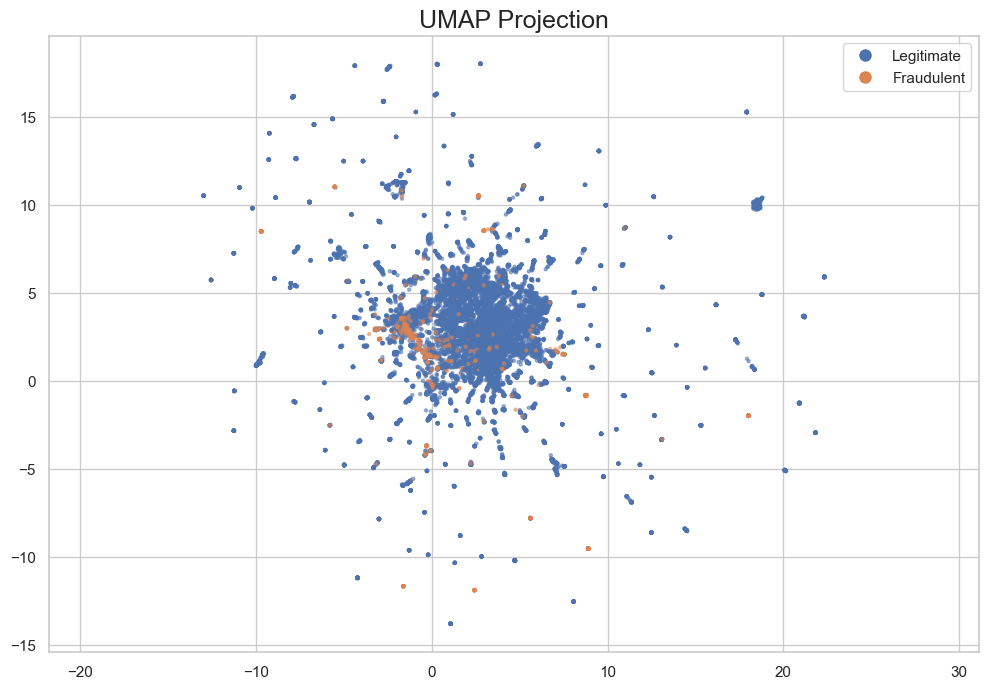

In [38]:
df['text'] = df['title'].fillna('') + " " + df['description'].fillna('')
tfidf = TfidfVectorizer(stop_words='english', max_features=2000)
X = tfidf.fit_transform(df['text'])

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

plt.figure(figsize=(12, 8))
plt.scatter(
    embedding[:, 0], 
    embedding[:, 1], 
    c=[sns.color_palette()[0] if x == 'f' else sns.color_palette()[1] for x in df['fraudulent']],
    s=5, 
    alpha=0.5
)
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP Projection', fontsize=18)
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Legitimate', markerfacecolor=sns.color_palette()[0], markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Fraudulent', markerfacecolor=sns.color_palette()[1], markersize=10)
])
plt.show()

It looks like there the data is clustered together, the fraudulent and real emails don't separate well, there might not be any immediate tells in the text, scammers send emails which mimic real emails. Although the low dimensional projection of the UMAP might not give us conclusive tells, we could still attempt SVM to find hyperplanes in a high dimensional space.

## **Data Cleaning**

### **Duplicates**

In [39]:
total_duplicates = df.duplicated(subset=['description']).sum()
print(total_duplicates)

# drop the duplicate rows
df_noduplicates = df.drop_duplicates(subset=['description'], keep='first')
print(df_noduplicates.shape)

2785
(15095, 19)


There are a lot of duplicate descriptions so instead of keeping duplicates, we just drop the duplicated rows so that we don't have double samples.

### **in_balanced_dataset column**

There is a in_balanced_dataset column, we filter and check what it is for

In [40]:
balanced = df[df['in_balanced_dataset'] == 't']
balanced_counts = balanced['fraudulent'].value_counts()
balanced_counts

fraudulent
t    450
f    450
Name: count, dtype: int64

In [41]:
notbalanced = df[df['in_balanced_dataset'] == 'f']
notbalanced_counts = notbalanced['fraudulent'].value_counts()
notbalanced_counts

fraudulent
f    16564
t      416
Name: count, dtype: int64

The ratio for the balanced dataset is 1:1, which is way different from the proportions of the other dataset. We should delete this column when training the model, so the model will not train based on this parameter from the traning data.

### **Turning all columns into usable features**

In [42]:
finaldf = df_noduplicates.drop(columns=['in_balanced_dataset'])
finaldf

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,"Marketing Intern <p>Food52, a fast-growing, Ja..."
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,Customer Service - Cloud Video Production <p>O...
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,Commissioning Machinery Assistant (CMA) <p>Our...
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,Account Executive - Washington DC <p><b>THE CO...
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,Bill Review Manager <p><b>JOB TITLE:</b> Itemi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17873,Recruiting Coordinator,"US, NC, Charlotte",NaN,NaN,NaN,<p><b>RESPONSIBILITIES:</b></p>\r\n<ul>\r\n<li...,<p><b>REQUIRED SKILLS:</b></p>\r\n<ul>\r\n<li>...,NaN,f,t,f,Contract,NaN,NaN,Utilities,NaN,f,Recruiting Coordinator <p><b>RESPONSIBILITIES:...
17875,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,<p>Vend is looking for some awesome new talent...,<p>Just in case this is the first time you’ve ...,<p>To ace this role you:</p>\r\n<ul>\r\n<li>Wi...,<p><b>What can you expect from us?</b></p>\r\n...,f,t,t,Full-time,Mid-Senior level,NaN,Computer Software,Sales,f,Account Director - Distribution <p>Just in ca...
17876,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,<p>WebLinc is the e-commerce platform and serv...,<p></p>\r\n<p>The Payroll Accountant will focu...,<p></p>\r\n<p>- B.A. or B.S. in Accounting</p>...,<p></p>\r\n<h3>Health &amp; Wellness</h3>\r\n<...,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,f,Payroll Accountant <p></p>\r\n<p>The Payroll A...
17877,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,<p>We Provide Full Time Permanent Positions fo...,<p>Experienced Project Cost Control Staff Engi...,<ul>\r\n<li>At least 12 years professional exp...,NaN,f,f,f,Full-time,NaN,NaN,NaN,NaN,f,Project Cost Control Staff Engineer - Cost Con...


## **Important Features**

### **1. Company Profiles**

In [43]:
finaldf1 = finaldf.copy()
finaldf1['profile_missing'] = finaldf1['company_profile'].isnull()


scamrate = finaldf1.groupby('profile_missing')['fraudulent'].apply(
    lambda x: (x == 't').mean() * 100
)

print(f"Fraud Rate (Profile Present): {scamrate[False]:.2f}%")
print(f"Fraud Rate (Profile Missing): {scamrate[True]:.2f}%")

Fraud Rate (Profile Present): 1.81%
Fraud Rate (Profile Missing): 14.87%


/var/folders/s7/bb8bc33j4ls6jvcncp_kcn7w0000gn/T/ipykernel_67984/1585355375.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=scamrate.index, y=scamrate.values, palette="Reds_r")


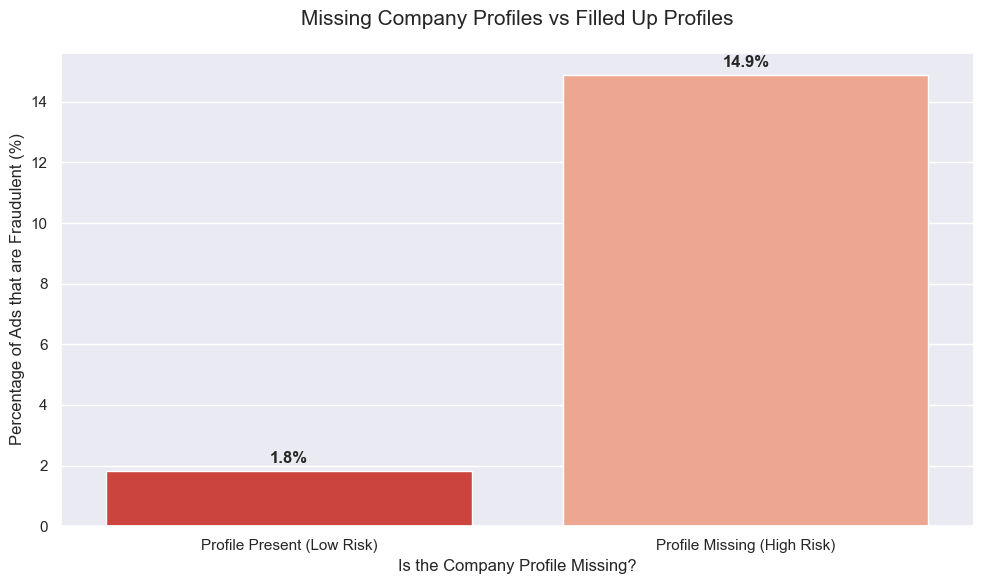

In [44]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=scamrate.index, y=scamrate.values, palette="Reds_r")

plt.title('Missing Company Profiles vs Filled Up Profiles', fontsize=15, pad=20)
plt.ylabel('Percentage of Ads that are Fraudulent (%)', fontsize=12)
plt.xlabel('Is the Company Profile Missing?', fontsize=12)
plt.xticks([0, 1], ['Profile Present (Low Risk)', 'Profile Missing (High Risk)'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

In [45]:
finaldf2 = finaldf.copy()

finaldf2['no_profile'] = finaldf2['company_profile'].isna().astype(int)

finaldf2['no_logo'] = ((finaldf2['has_company_logo'] == 'f') | (finaldf2['has_company_logo'].isna())).astype(int)

finaldf2['suspicion_score'] = finaldf2['no_profile'] + finaldf2['no_logo']

print("Distribution of Suspicion Scores:")
print(finaldf2['suspicion_score'].value_counts().sort_index())

combined_analysis = finaldf2.groupby('suspicion_score')['fraudulent'].apply(
    lambda x: (x == 't').mean() * 100
)

print("\nFraud Rate per Score (%):")
print(combined_analysis)

Distribution of Suspicion Scores:
suspicion_score
0    11260
1     1515
2     2320
Name: count, dtype: int64

Fraud Rate per Score (%):
suspicion_score
0     1.873890
1     1.584158
2    18.275862
Name: fraudulent, dtype: float64


/var/folders/s7/bb8bc33j4ls6jvcncp_kcn7w0000gn/T/ipykernel_67984/1872771095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=combined_analysis.index, y=combined_analysis.values, palette=colors)


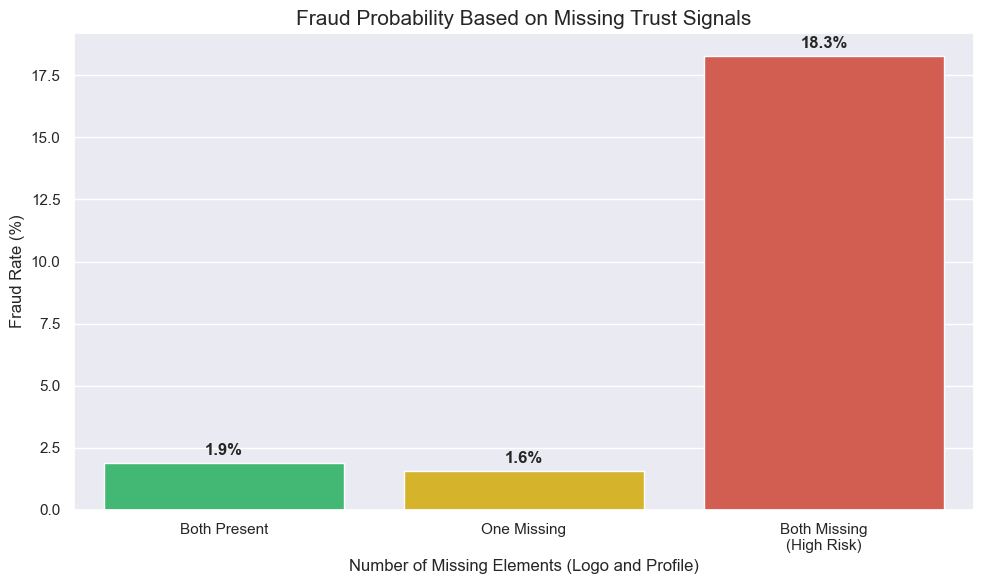

In [46]:
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f1c40f', '#e74c3c']
ax = sns.barplot(x=combined_analysis.index, y=combined_analysis.values, palette=colors)

plt.title('Fraud Probability Based on Missing Trust Signals', fontsize=15)
plt.xlabel('Number of Missing Elements (Logo and Profile)', fontsize=12)
plt.ylabel('Fraud Rate (%)', fontsize=12)
plt.xticks([0, 1, 2], ['Both Present', 'One Missing', 'Both Missing\n(High Risk)'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/s7/bb8bc33j4ls6jvcncp_kcn7w0000gn/T/ipykernel_67984/3928737184.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=analysis.values, y=analysis.index, palette="viridis")


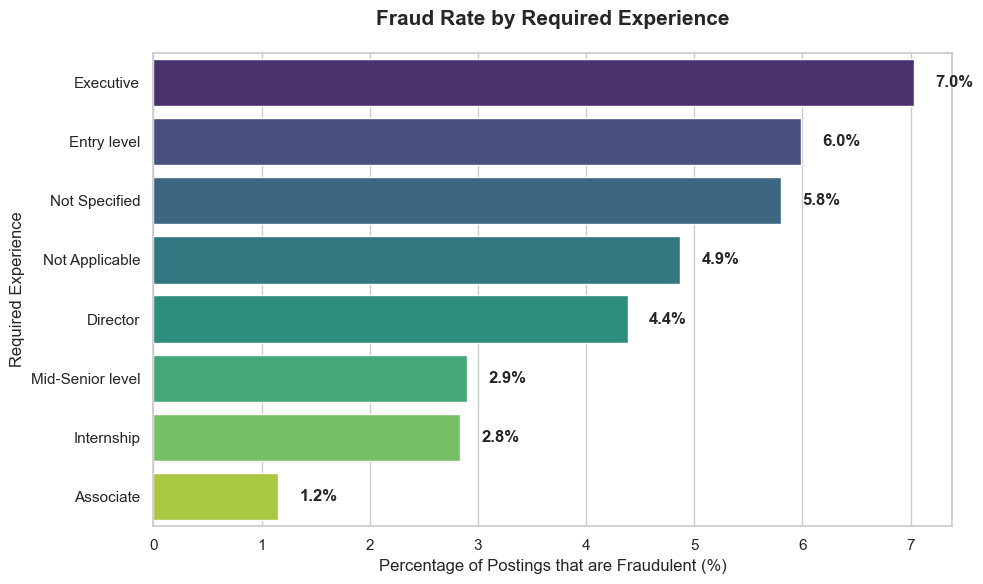

/var/folders/s7/bb8bc33j4ls6jvcncp_kcn7w0000gn/T/ipykernel_67984/3928737184.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=analysis.values, y=analysis.index, palette="viridis")


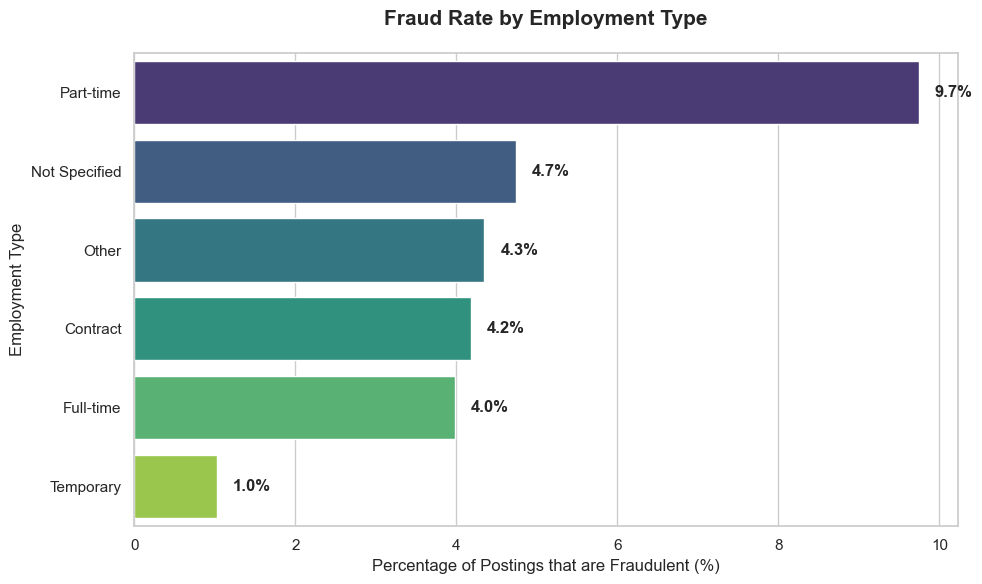

In [47]:
finaldf['is_fraud_numeric'] = (finaldf['fraudulent'] == 't').astype(int)

# fill missing values
finaldf['required_experience'] = finaldf['required_experience'].fillna('Not Specified')
finaldf['employment_type'] = finaldf['employment_type'].fillna('Not Specified')

def plot_fraud_distribution(df, column, title):

    analysis = df.groupby(column)['is_fraud_numeric'].mean().sort_values(ascending=False) * 100
    
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    ax = sns.barplot(x=analysis.values, y=analysis.index, palette="viridis")
    
    plt.title(f'Fraud Rate by {title}', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Percentage of Postings that are Fraudulent (%)', fontsize=12)
    plt.ylabel(title, fontsize=12)
    
    for i, v in enumerate(analysis.values):
        ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_fraud_distribution(finaldf, 'required_experience', 'Required Experience')

plot_fraud_distribution(finaldf, 'employment_type', 'Employment Type')